# Imports & Helper Functions
Check this code runs which means all the installations should be correct.

In [1]:
import cv2
import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np

import os

from sklearn.cluster import KMeans

# helper function to easily plot + save images at the same time - useful for debugging
def imshow(image, name="image.png", plot=True, write=True, cmap="gist_gray"):
    if write:
        bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        cv2.imwrite(name, bgr)
    if plot:
        plt.figure(figsize=(9, 9))
        plt.imshow(image, cmap=cmap)
        plt.axis('off')  
        
def load_rgb(path):
    img = cv2.imread(path)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return rgb
# cv2 doesn't automatically load images in an RGB format but in a BGR format 
# so I wanted to create a helper function which helps with more easily plotting images


# Task 1 - Identifying the Canvas
- In order to extract the canvas from a screenshot of the GUI - canny edge detection can be used to segment large enclosed shapes. 

- We can follow the _assumption_ that the contour with the largest enclosed area within a design app screenshot is the canvas.

- Sometimes the canvas will intersect with the edge of the screenshot, which means the edge of the canvas will not be detected - to combat this we can add a border or padding to the image and then later remove it.

- The border colour is chosen based on whether the GUI is in light mode or dark mode
These assumptions can be made:
```
if the GUI is in light mode this usually means the canvas colour is dark
if the GUI is in dark mode this usally means the canvas colour is white
```
These assumptions do have limitations - when the canvas becomes much more complex and populated this method will likely be unsuccessful. 


- Once edges have been detected we can use `cv2.findContours` to find contours and then sort them in terms of area to find the largest enclosed contour

Resources:
- https://www.geeksforgeeks.org/python/adding-borders-to-the-images-using-python-opencv/
- https://www.learningaboutelectronics.com/Articles/How-to-find-the-largest-or-smallest-object-in-an-image-Python-OpenCV.php

Extension: Ideally I would want to find an algorithm to automatically identify whether a black or white border is needed to support edge detection i.e. working out whether the canvas is white or dark. An initial idea was to use the most common pixel colour to make a best guess. I could validate this by checking the canvas occupies a certain ratio of the screen. 

In [2]:
# Initial Implementation
def find_canvas(image, light_mode=True):
    if light_mode:
        val = 255 # border = white
    else:
        val = 0 # border = black
        
    pad = 10
    
    bordered_frame = cv2.copyMakeBorder(image, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=[val, val, val])
    
    gray= cv2.cvtColor(bordered_frame,cv2.COLOR_BGR2GRAY)
    
    ret,thresh = cv2.threshold(gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    
    edges = cv2.Canny(thresh, 0, 200)
    # imshow(edges, write=False) # optional code to show inbetween step for debugging
    
    contours, hierarchy= cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    sorted_contours= sorted(contours, key=cv2.contourArea, reverse= True) # find largest contour area
    canvas_contour = sorted_contours[0] # the largest contour area will usually be the canvas; following assumptions laid out above
    
    return canvas_contour - pad # remove border from contours

## Testing with Figma

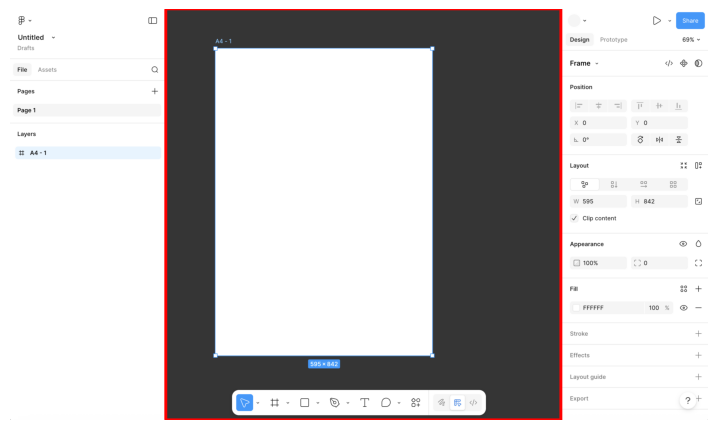

In [3]:
image = load_rgb('sample-data/figma.png')
canvas = find_canvas(image, light_mode=True)
cv2.drawContours(image, canvas, -1, (255,0,0),10)
imshow(image, write=False)

## Testing with Illustrator - including canvas occlusion 

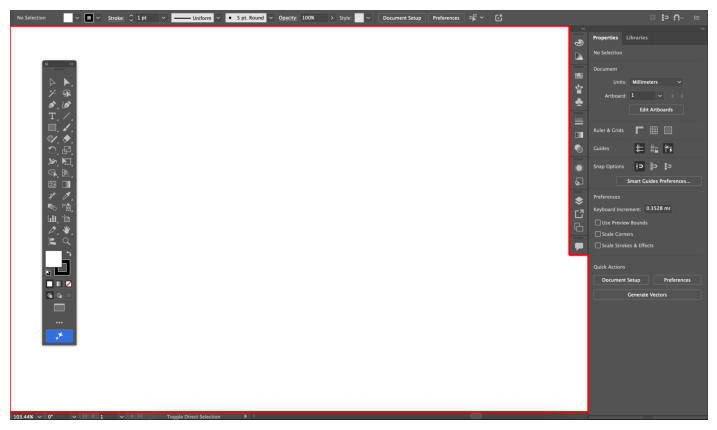

In [4]:
image = load_rgb('sample-data/illustrator-1.png')
canvas = find_canvas(image, light_mode=False)
cv2.drawContours(image, canvas, -1, (255,0,0),5)
imshow(image, write=False)

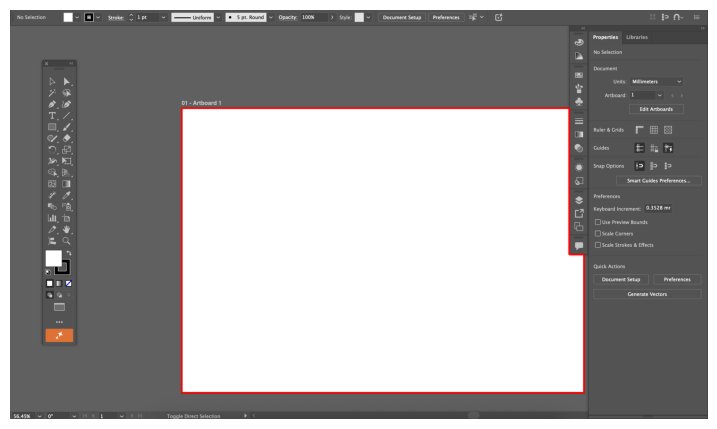

In [5]:
image = cv2.imread('sample-data/illustrator-3.png')
canvas = find_canvas(image, light_mode=False)
cv2.drawContours(image, canvas, -1, (255,0,0),5)
imshow(image, write=False)

## Extension/subtask - Automatically identifying canvas colour
Potential ideas:

1. Find most common pixel colour in an image (limitation: this doesn't necessarily correspond to canvas colour or lightmode or darkmode e.g. if th canvas has been zoomed out significantly in illustrator this wouldn't work)

2. Segment image based on colours (limitation: similar to first idea)

3. Take a segment of the screenshot (middle region) - following the assumption that the canvas is usually in the centre of the image and perform segmentation there.

4. Find a region of high entropy - this will suggest a region of dense icons rather than the blank canvas - then find the background colour for that region. May be possible to try top hat or bottom hat here ... do a bit more reading ...

---

# Task 2 - Extracting GUI Elements

Algorithm overview:
1. convert to grayscale - which is important before thresholding
2. manullay threshold
3. if in light-mode flip the image (if the screenshot is in light-mode this will mean the icons are black on a white background and we would want to flip this so that white presents positive values)
4. dilate the new image to merge small points between GUI icons together so they are a single blob - this will allow us to model each icon as a connected compoent
5. find connected components within a specific size range (area > 300) and (area < 9000) - these valually were manually discovered through iterative investigations (if I have time it would be good to update these from an area to a specific fraction of the screen they occupy so this method is transferrable to screenshots of different sizes)

In [7]:
def prepare_for_connected_components(image, light_mode=True):
    # this assumes the input image is in RGB space
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    # ret, thresh = cv2.threshold(gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    # I initially tried otsu's binarisation but found that manually defining thresholds works better:
    
    # binarise the image:
    ret, thresh = cv2.threshold(gray, 190, 255, cv2.THRESH_BINARY)
    
    # if the screenshot is in light-mode this will mean the icons are black on a white background and we would want to flip this
    if light_mode:
        pre_dilated = cv2.bitwise_not(thresh)
    else:
        pre_dilated = thresh
    
    # by dilating the image this will cause small points between icons to become merged together e.g. a single blob
    # this will allow us to model each icon as a connected compoent
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(11,11))
    dilated = cv2.dilate(pre_dilated,kernel,iterations = 1)
    # as an alternative a closing operation could be used which would close small gaps between objects - but dilation works well enough here
    
    return dilated
        

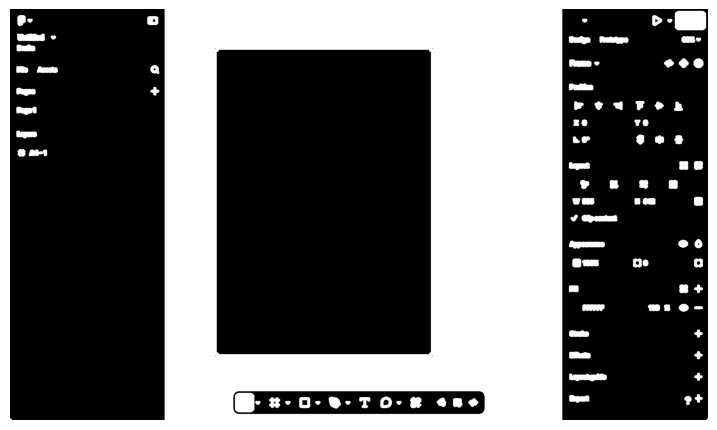

In [8]:
image = load_rgb('sample-data/figma.png')
processed = prepare_for_connected_components(image)
imshow(processed, write=False)

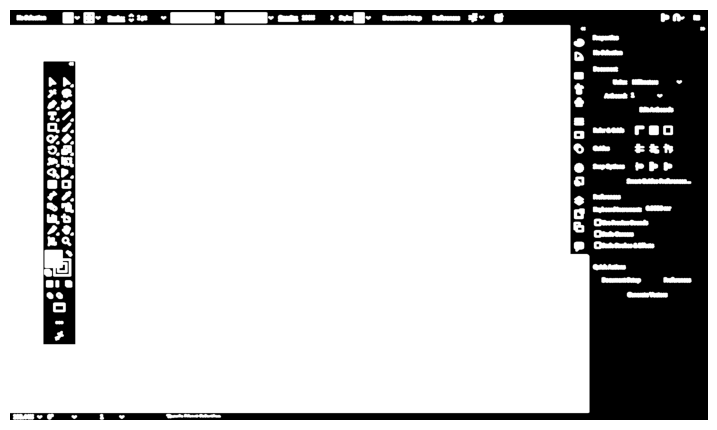

In [9]:
image = load_rgb('sample-data/illustrator-1.png')
processed = prepare_for_connected_components(image, light_mode=False)
imshow(processed, write=False)

In [ ]:
def extract_icons(image, light_mode=True, icon_list="dataset-1"):
    processed = prepare_for_connected_components(image, light_mode)
    
    analysis = cv2.connectedComponentsWithStats(processed, 4, cv2.CV_32S) # what is CV_32S? would be good to research more
    
    (totalLabels, label_ids, stats, centroids) = analysis
    
    img_h = image.shape[0]
    img_w = image.shape[1]
    
    
    overlay = image.copy() # crete an overlay to place over the image
    cv2.rectangle(overlay, (0, 0), (img_w, img_h), (0, 0, 0), -1) # convert to a black overlay
    
    # add shading so icons are clearer to see
    alpha = 0.8 
    shaded = cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0) # place shade over the original image
    bounding_boxes = shaded.copy()
    
    centres_dataset = []
    
    for i in range(1, totalLabels):
        area = stats[i, cv2.CC_STAT_AREA]  

        if (area > 300) and (area < 9000):
            
            (cX, cY) = centroids[i]
            
            x = stats[i, cv2.CC_STAT_LEFT]
            y = stats[i, cv2.CC_STAT_TOP]
            w = stats[i, cv2.CC_STAT_WIDTH]
            h = stats[i, cv2.CC_STAT_HEIGHT]
            # area = stats[i, cv2.CC_STAT_AREA]
                
            cv2.rectangle(bounding_boxes, (x, y), (x+w, y+h), (255, 0, 0), 2)
            cropped_im = processed[y:y+h, x:x+w]
            
            dataset_path = f"./icon-datasets/{icon_list}"
            
            if not os.path.exists(dataset_path):
                os.makedirs(dataset_path)
            
            cv2.imwrite(f"{dataset_path}/icon-{i}.png", cropped_im) # save icon to a collection of icons for further analysis
            
            centres_dataset.append([cX, cY])
        
    return bounding_boxes, centres_dataset
    

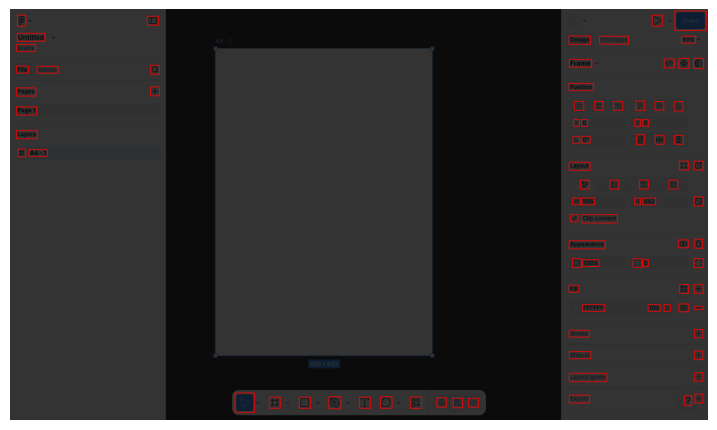

In [22]:
image = load_rgb('sample-data/figma.png')
bounding_boxes, centres = extract_icons(image, light_mode=True, icon_list="dataset-1")
imshow(bounding_boxes, write=False)